<a href="https://colab.research.google.com/github/manikanta5315/sentiment-analysis-tfidf-vs-sbert/blob/main/Project_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Sentiment Analysis Pipeline
Trains and evaluates TF-IDF and SBERT-based sentiment classifiers
on the Sentiment140 dataset.
"""

'\nSentiment Analysis Pipeline\nTrains and evaluates TF-IDF and SBERT-based sentiment classifiers\non the Sentiment140 dataset.\n'

In [2]:
from google.colab import userdata
import os
os.environ['KAGGLE_USERNAME']= userdata.get('kaggle_username')
os.environ['KAGGLE_KEY'] = userdata.get('kaggleAPI')

In [3]:
import pandas as pd
import numpy as np
import re
import time
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix, classification_report

nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
!pip install sentence-transformers
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import SGDClassifier

In [5]:
!pip install kaggle -q

In [6]:
!kaggle datasets download -d kazanova/sentiment140 --force

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
100% 80.9M/80.9M [00:00<00:00, 87.4MB/s]



In [7]:
!unzip -o sentiment140.zip

Archive:  sentiment140.zip
  inflating: training.1600000.processed.noemoticon.csv  


In [8]:
#Reading the data which is downloaded from kaggle and unzipped. And also using only two columns.
data = pd.read_csv("training.1600000.processed.noemoticon.csv", encoding= 'latin-1', header = None, names= ['target', 'id', 'date', 'flag', 'user', 'text'], usecols= ['target', 'text'])

In [9]:
data.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [10]:
data.isna().sum()

,0
target,0
text,0


In [11]:
data.duplicated().sum() #duplicates found

np.int64(16309)

In [12]:
#dropping the duplicates and null attributes.
data = data.drop_duplicates(subset = ['text'])
data = data.dropna(subset=['text'])

In [13]:
data.target.value_counts()

,count
target,
4,791281
0,790185


In [14]:
pd.set_option('display.max_colwidth', None)

In [15]:
data.text.head()

,text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."


##Preprocessing tweets

In [16]:
#Applied all the cleaning steps includes cleaning, substituting, tokenizing, stopwords, stemming and joining the tweets.
stop_words = set(stopwords.words('english')) - {'not', 'no', 'nor', 'never', 'none', 'neither'}
stemmer = PorterStemmer()

def clean_text_classical(text):
  text = re.sub(r'@\w+', '', text)
  text = re.sub(r'http\S+', '', text)
  text = text.lower()
  text = re.sub(r'[^a-zA-Z\s]', '', text)
  text = word_tokenize(text)
  text = [i for i in text if i not in stop_words]
  text = [stemmer.stem(i) for i in text]

  return ' '.join(text)

In [17]:
#Applied only few cleaning steps, sbert embedding are already learned on its own tokenization and
#sbert expects the tweets should be in natural meaningful language.
def clean_text_sbert(text):
    """For SBERT — light cleaning only, preserve natural sentence structure."""
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+', '', text)
    return text.strip()

In [18]:
data.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,0,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,0,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."


In [19]:
data['target'] = data['target'].replace({0: 0, 4: 1})

# Keeping both versions, same rows
data['text_classical'] = data['text'].apply(clean_text_classical)
data['text_sbert'] = data['text'].apply(clean_text_sbert)

# Splitting the data

In [20]:
# Splitting once — using the original data, keeps both columns aligned to the same rows
X_temp, X_test, Y_temp, Y_test = train_test_split(data[['text_classical', 'text_sbert']], data['target'], random_state=42, test_size=0.1)
X_train, X_valid, Y_train, Y_valid = train_test_split(X_temp, Y_temp, random_state=42, test_size=0.2)

# Then extracting each version for its respective pipeline
X_train_classical, X_train_sbert = X_train['text_classical'], X_train['text_sbert']
X_valid_classical, X_valid_sbert = X_valid['text_classical'], X_valid['text_sbert']
X_test_classical, X_test_sbert = X_test['text_classical'], X_test['text_sbert']

#First Using TfidfVectorizer

In [21]:
#Transforming the splitted data into the vector format using TfidfVectorizer.
vector = TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True, min_df=2)

start = time.time()

x_train_vec = vector.fit_transform(X_train_classical)
tfidf_time = time.time() - start
print("Train encoding time:", tfidf_time)

x_valid_vec = vector.transform(X_valid_classical)
x_test_vec = vector.transform(X_test_classical)

Train encoding time: 22.86347270011902


#Modeling with LogisticRegression on the vectorized data

In [22]:
#Choosing the logisticRegresson, It works on linear classifictaion which is suitable for this usecase.
lr_vect_model = LogisticRegression(C=1.5, penalty='l2', solver='lbfgs', max_iter=1000, n_jobs = -1, verbose = 1)

lr_vect_model.fit(x_train_vec, Y_train)
prediction_vec = lr_vect_model.predict(x_valid_vec)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


In [23]:
lr_vect_model_accuracy = accuracy_score(Y_valid, prediction_vec)
print("TF-IDF Logistic Regression Accuracy:", lr_vect_model_accuracy)

lr_vect_model_f1 = f1_score(Y_valid, prediction_vec)
print("TF-IDF Logistic Regression F1:", lr_vect_model_f1)

TF-IDF Logistic Regression Accuracy: 0.8046679594188236
TF-IDF Logistic Regression F1: 0.8067225138169557


#Tuning on the gridsearchCV

In [24]:
#Using gridsearchCV

X_sample_vec, _, y_sample_vec, _ = train_test_split(
    x_train_vec, Y_train,
    train_size=30000,   # tune on 150K rows instead of 1M+
    stratify=Y_train,
    random_state=42
)


param_grid_vec = [
    {'solver': ['lbfgs'], 'penalty': ['l2'], 'C': [0.01, 0.1, 1, 1.5, 2]},
    {'solver': ['liblinear'], 'penalty': ['l1', 'l2'], 'C': [0.01, 0.1, 1, 10]}]

grid_vec = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_vec, cv=5, scoring='f1', n_jobs=-1, verbose=2)

start = time.time()
grid_vec.fit(X_sample_vec, y_sample_vec)
print(f"GridSearch fit time: {time.time()-start} sec")

print("Best params:", grid_vec.best_params_)
print("Best CV F1:", grid_vec.best_score_)

y_valid_pred_vec = grid_vec.best_estimator_.predict(x_valid_vec)
print("Tuned vector Valid F1:", f1_score(Y_valid, y_valid_pred_vec))
print("Tuned vector Valid Accuracy:", accuracy_score(Y_valid, y_valid_pred_vec))

Fitting 5 folds for each of 13 candidates, totalling 65 fits
GridSearch fit time: 70.88623523712158 sec
Best params: {'C': 2, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1: 0.7674162145789296
Tuned vector Valid F1: 0.7713373142619081
Tuned vector Valid Accuracy: 0.7686254672174915


In [25]:
final_lr_vec_model = LogisticRegression(**grid_vec.best_params_, max_iter=1000, n_jobs=-1, verbose=1)
final_lr_vec_model.fit(x_train_vec, Y_train)

final_prediction_vec = final_lr_vec_model.predict(x_valid_vec)

final_accuracy_vec = accuracy_score(Y_valid, final_prediction_vec)
final_f1_vec = f1_score(Y_valid, final_prediction_vec)

print("FINAL Tuned TF-IDF Accuracy (full data):", final_accuracy_vec)
print("FINAL Tuned TF-IDF F1 (full data):", final_f1_vec)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


FINAL Tuned TF-IDF Accuracy (full data): 0.8048330663519097
FINAL Tuned TF-IDF F1 (full data): 0.8066351799580255


In [26]:
import gc
del x_train_vec, x_valid_vec
gc.collect()

203

In [27]:
import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


##Second using SBERT Transformer

In [28]:
sbert_model = SentenceTransformer('all-MiniLM-L6-v2', device='cuda')

start = time.time()
x_train_sbert = sbert_model.encode(X_train_sbert.to_list(),batch_size=128, show_progress_bar=True)
sbert_time = time.time() - start
print("Train encoding time:", sbert_time)

x_valid_sbert = sbert_model.encode(X_valid_sbert.to_list(),batch_size=128, show_progress_bar=True)
x_test_sbert = sbert_model.encode(X_test_sbert.to_list(),batch_size=128, show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/8896 [00:00<?, ?it/s]

Train encoding time: 391.3924009799957


Batches:   0%|          | 0/2224 [00:00<?, ?it/s]

Batches:   0%|          | 0/1236 [00:00<?, ?it/s]

In [29]:
import psutil
print(f"RAM used: {psutil.virtual_memory().percent}%")

RAM used: 63.2%


In [30]:
import joblib
from google.colab import files

save_dir = '/content/sentiment140_project'
os.makedirs(save_dir, exist_ok=True)

# Saving  the trained SBERT model
joblib.dump(sbert_model, f'{save_dir}/sbert_model.pkl')

# Saving embeddings
np.save(f'{save_dir}/x_train_sbert.npy', x_train_sbert)
np.save(f'{save_dir}/x_valid_sbert.npy', x_valid_sbert)
np.save(f'{save_dir}/x_test_sbert.npy', x_test_sbert)

np.save(f'{save_dir}/y_train.npy', Y_train.to_numpy() if hasattr(Y_train, 'to_numpy') else Y_train)
np.save(f'{save_dir}/y_valid.npy', Y_valid.to_numpy() if hasattr(Y_valid, 'to_numpy') else Y_valid)
np.save(f'{save_dir}/y_test.npy', Y_test.to_numpy() if hasattr(Y_test, 'to_numpy') else Y_test)

print("Saved locally on Colab.")

Saved locally on Colab.


In [31]:
#This grabage collector will wipeout all the RAM consumed on training embedings which are deleted.
import gc
del sbert_model, x_train_sbert, x_valid_sbert, x_test_sbert
gc.collect()

1973

In [32]:
import joblib
import numpy as np

save_dir = '/content/sentiment140_project'

# Loading the SBERT model
sbert_model = joblib.load(f'{save_dir}/sbert_model.pkl')

# Loading embeddings
x_train_sbert = np.load(f'{save_dir}/x_train_sbert.npy')
x_valid_sbert = np.load(f'{save_dir}/x_valid_sbert.npy')
x_test_sbert  = np.load(f'{save_dir}/x_test_sbert.npy')

Y_train = np.load(f'{save_dir}/y_train.npy')
Y_valid = np.load(f'{save_dir}/y_valid.npy')
Y_test  = np.load(f'{save_dir}/y_test.npy')

print("Loaded successfully — shapes:", x_train_sbert.shape, x_valid_sbert.shape, x_test_sbert.shape)

Loaded successfully — shapes: (1138655, 384) (284664, 384) (158147, 384)


#Modeling with SGDClassifier on SBERT Embeddings

In [33]:

#lr_sbert_model = LogisticRegression(max_iter = 1000, verbose=1, n_jobs = -1, penalty='l2', solver='lbfgs')
# logisticRegression with sbert model is  causing the session carsh out of ram.
# so, choosing the SGDClassifier where it updates the model weight sample by sample like mini-batches.

sgd_classifier = SGDClassifier(loss='log_loss', penalty='l1', alpha=0.0001, max_iter = 1000,fit_intercept=True, shuffle=True, tol=1e-3, random_state=42)

sgd_classifier.fit(x_train_sbert, Y_train)
prediction_sbert = sgd_classifier.predict(x_valid_sbert)

In [34]:
sgd_sbert_model_accuracy = accuracy_score(Y_valid, prediction_sbert)
print("SBERT sbert sgd classifier Accuracy:", sgd_sbert_model_accuracy)

sgd_sbert_model_f1 = f1_score(Y_valid, prediction_sbert)
print("SBERT sgd_classifier f1_score:", sgd_sbert_model_f1)

SBERT sbert sgd classifier Accuracy: 0.7712952814546272
SBERT sgd_classifier f1_score: 0.7717411121239744


In [35]:
#Using gridsearchCV tunining on 3000 samples

X_sample, _, y_sample, _ = train_test_split(
    x_train_sbert, Y_train,
    train_size=30000,
    stratify=Y_train,
    random_state=42
)

param_grid_sbert = {'loss': ['log_loss'], 'penalty': ['l2'], 'alpha': [1e-6, 1e-5, 1e-4, 1e-3]}

grid_sbert = GridSearchCV(SGDClassifier(max_iter=1000, random_state=42), param_grid_sbert, cv=3, scoring='f1', verbose=2, n_jobs =2)

start = time.time()
grid_sbert.fit(X_sample, y_sample)
print(f"GridSearch fit time: {time.time()-start:.2f} sec")

print("Best params:", grid_sbert.best_params_)
print("Best CV F1:", grid_sbert.best_score_)

y_valid_pred_sbert = grid_sbert.best_estimator_.predict(x_valid_sbert)
print("Tuned SBERT Valid F1:", f1_score(Y_valid, y_valid_pred_sbert))
print("Tuned SBERT Valid Accuracy:", accuracy_score(Y_valid, y_valid_pred_sbert))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
GridSearch fit time: 15.64 sec
Best params: {'alpha': 0.0001, 'loss': 'log_loss', 'penalty': 'l2'}
Best CV F1: 0.7679977831402409
Tuned SBERT Valid F1: 0.7693604822730914
Tuned SBERT Valid Accuracy: 0.7693702048731136


In [36]:
print(grid_sbert.best_params_)

{'alpha': 0.0001, 'loss': 'log_loss', 'penalty': 'l2'}


In [37]:
final_sgd_sbert_model =  SGDClassifier(**grid_sbert.best_params_, max_iter = 1000, verbose=1, n_jobs = -1)
final_sgd_sbert_model.fit(x_train_sbert, Y_train)

final_predection_sgd_sbert_model = final_sgd_sbert_model.predict(x_valid_sbert)

final_accuracy_sbert = accuracy_score(Y_valid, final_predection_sgd_sbert_model)
final_f1_sbert = f1_score(Y_valid, final_predection_sgd_sbert_model)

print("FINAL Tuned sbert Accuracy (full data):", final_accuracy_sbert)
print("FINAL Tuned sbert F1 (full data):", final_f1_sbert)

-- Epoch 1
Norm: 16.76, NNZs: 384, Bias: 0.085237, T: 1138655, Avg. loss: 0.483838
Total training time: 1.83 seconds.
-- Epoch 2
Norm: 16.69, NNZs: 384, Bias: -0.042469, T: 2277310, Avg. loss: 0.478162
Total training time: 4.33 seconds.
-- Epoch 3
Norm: 16.67, NNZs: 384, Bias: -0.126373, T: 3415965, Avg. loss: 0.477939
Total training time: 6.56 seconds.
-- Epoch 4
Norm: 16.62, NNZs: 384, Bias: -0.123874, T: 4554620, Avg. loss: 0.477822
Total training time: 8.37 seconds.
-- Epoch 5
Norm: 16.70, NNZs: 384, Bias: -0.083211, T: 5693275, Avg. loss: 0.477797
Total training time: 10.19 seconds.
-- Epoch 6
Norm: 16.56, NNZs: 384, Bias: -0.028553, T: 6831930, Avg. loss: 0.477878
Total training time: 12.00 seconds.
-- Epoch 7
Norm: 16.76, NNZs: 384, Bias: -0.098703, T: 7970585, Avg. loss: 0.477639
Total training time: 13.85 seconds.
Convergence after 7 epochs took 13.85 seconds
FINAL Tuned sbert Accuracy (full data): 0.7726899081021836
FINAL Tuned sbert F1 (full data): 0.772829563367376


#Final test prediction with the model logistic regression and TF-IDF vectorizer

In [38]:
#Choosing the final usecase model which performed very well comparing with the other model, and the best parameters of the choosen moodel.
final_test_prediction = final_lr_vec_model.predict(x_test_vec)

test_accuracy = accuracy_score(Y_test, final_test_prediction)
test_f1 = f1_score(Y_test, final_test_prediction)
precision = precision_score(Y_test, final_test_prediction)
recall = recall_score(Y_test, final_test_prediction)

print("Test Accuracy:", test_accuracy)
print("Test F1:", test_f1)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Test Accuracy: 0.8055796189621048
Test F1: 0.8080603779238534
Precision: 0.7988
Recall: 0.8175


In [39]:
print(classification_report(Y_test, final_test_prediction))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80     78976
           1       0.80      0.82      0.81     79171

    accuracy                           0.81    158147
   macro avg       0.81      0.81      0.81    158147
weighted avg       0.81      0.81      0.81    158147



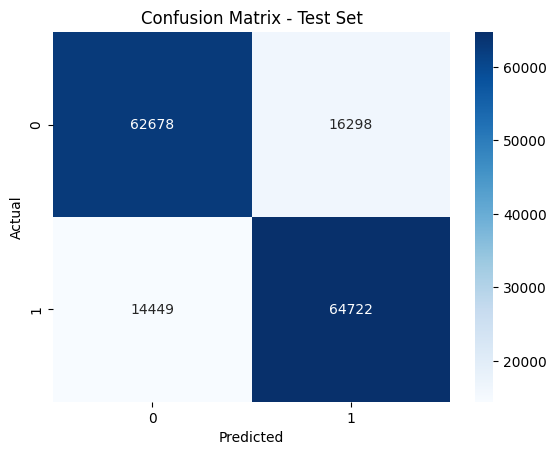

In [40]:
#Confusion matrics on test set.
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, final_test_prediction)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.show()

In [41]:
print(f"TF-IDF vectorization time: {tfidf_time:.2f}s")
print(f"SBERT encoding time: {sbert_time:.2f}s")

TF-IDF vectorization time: 22.86s
SBERT encoding time: 391.39s


In [42]:
joblib.dump(final_lr_vec_model, f'{save_dir}/final_sentiment_model.pkl')
joblib.dump(vector, f'{save_dir}/tfidf_vectorizer.pkl')

['/content/sentiment140_project/tfidf_vectorizer.pkl']

#Checking & Predicting on unseen tweet

In [43]:
def predict_sentiment_vec(text, vectorizer = vector, classifier = final_lr_vec_model):
  text = clean_text_classical(text)
  vector_input = vectorizer.transform([text])
  prediction = classifier.predict(vector_input)[0]
  return "Positive" if prediction == 1 else "Negative"

print(predict_sentiment_vec("I absolutely loved this!"))

Positive


## Project Summary

This project builds and compares two sentiment classification approaches on the
Sentiment140 dataset (1.6M tweets, binary sentiment: negative/positive): a
classical TF-IDF + Logistic Regression pipeline, and a modern SBERT embedding +
SGDClassifier pipeline.

## Data Preparation

- Removed duplicate and null tweets from the raw dataset
- Relabeled the original Sentiment140 targets (0 = negative, 4 = positive) to
  0/1 for binary classification
- Built two separate text-cleaning pipelines, since the two modeling approaches
  require fundamentally different input:
  - **Classical pipeline** (`clean_text_classical`): regex cleaning (mentions,
    URLs), lowercasing, tokenization, stopword removal, and Porter stemming —
    standard preparation for bag-of-words methods like TF-IDF, which benefit
    from a reduced, normalized vocabulary
  - **SBERT pipeline** (`clean_text_sbert`): minimal cleaning (mentions, URLs
    only). SBERT's transformer architecture was trained on natural, fluent
    sentences, and its own internal subword tokenizer handles the rest —
    stemming and stopword removal strip grammatical structure and mangle
    words (e.g. "loved" → "love") in ways that hurt a model built to
    understand contextual meaning rather than word frequency. Initially I
    fed SBERT the same aggressively-cleaned text built for TF-IDF, which
    turned out to be a significant, measurable mistake (see Results below)
- One correction made during cleaning: NLTK's default English stopword list
  includes negation words ("not", "no", "never", etc.). Removing these would
  flip the meaning of negated sentences (e.g. "not good" → "good" after
  cleaning), so these were explicitly excluded from the stopword set

## Modeling Approach 1: TF-IDF + Logistic Regression

- Vectorized cleaned text with `TfidfVectorizer(ngram_range=(1,2),
  sublinear_tf=True, min_df=2)`
- Baseline Logistic Regression: **80.47% accuracy, 80.67% F1**
- Tuned hyperparameters via `GridSearchCV` (on a 30,000-row stratified
  subsample, for tractability) across solver, penalty, and C
- Best parameters: `C=2, penalty='l2', solver='lbfgs'`
- **Final validation accuracy: 80.48%, F1: 80.66%**

## Modeling Approach 2: SBERT + SGDClassifier

- Encoded cleaned tweets into 384-dimensional embeddings using
  `all-MiniLM-L6-v2`
- Initially attempted `LogisticRegression`, but this repeatedly crashed the
  Colab session due to RAM exhaustion — `lbfgs`/`liblinear` solvers upcast
  data to float64 and hold multiple working copies during optimization,
  which exceeded available memory on the full 1.1M+ row training set
- Switched to `SGDClassifier`, which trains incrementally (`partial_fit`-
  style, via mini-batches) and avoids holding the full dataset in an
  expanded form in memory at once
- Baseline SGDClassifier: **77.13% accuracy, 77.17% F1**
- Tuned via `GridSearchCV` on a 30,000-row stratified subsample. Best
  parameters: `alpha=0.0001, loss='log_loss', penalty='l2'`
- L2 was compared against L1 regularization: L2 kept all 384 embedding
  dimensions active, while L1 zeroed out roughly half — consistent with the
  expectation that dense, information-packed embeddings don't benefit from
  L1's sparsity the way TF-IDF's high-dimensional sparse features do. L2
  performed marginally better and trained faster
- **Final validation accuracy: 77.26%, F1: 77.09%**

## A Pipeline Bug I Found and Fixed

Early in this project, SBERT's validation accuracy sat around 73%, noticeably
below TF-IDF. Rather than accept "embeddings underperform classical methods"
at face value, I investigated further:

- Tested L1 vs L2 regularization — no meaningful difference, ruling this out
- Ran a non-linear SVM (RBF kernel) as a diagnostic on a subsample —
  performance stayed similar, ruling out "linear boundary limitation"
- Realized the actual cause: I was feeding SBERT the same aggressively
  cleaned text (stemmed, stopwords removed) built for TF-IDF. SBERT was
  trained on natural, grammatically intact sentences — feeding it fragments
  like "movi great not slow" is out-of-distribution input for its tokenizer

After separating the cleaning pipelines (light cleaning for SBERT, preserving
natural sentence structure), SBERT's validation accuracy improved from 73.3%
to **77.26%** — a substantial, measurable gain, confirming the diagnosis.
This is a well-known but easy-to-miss pattern: classical bag-of-words
methods benefit from heavy text normalization, while transformer-based
embeddings expect natural language and are actively hurt by it.

## Comparison

| Model | Validation Accuracy | Validation F1 | Encoding Time (train) |
|---|---|---|---|
| TF-IDF + Logistic Regression | 80.48% | 80.66% | 21.74s |
| SBERT + SGDClassifier | 77.26% | 77.09% | 496.76s |

TF-IDF outperformed SBERT here, and trained roughly 23x faster. The most
likely explanation is that `all-MiniLM-L6-v2` is a general-purpose sentence
embedding model, not fine-tuned for sentiment or for informal, slang-heavy
tweet text — while TF-IDF, paired with a classifier, learns word-sentiment
correlations directly from this exact dataset. This suggests that for short,
informal, domain-specific text, a frozen general-purpose embedding doesn't
automatically beat a well-tuned classical approach — though the gap narrowed
substantially once SBERT was given properly formatted input.

## Final Model & Test Set Evaluation

Based on validation performance, **TF-IDF + Logistic Regression** was
selected as the final model. Evaluated once on the held-out test set for an
unbiased final estimate:

- **Test Accuracy: 80.56%**
- **Test F1: 80.81%**
- **Precision: 79.88%**
- **Recall: 81.75%**

precision    recall  f1-score   support
       0       0.81      0.79      0.80     78976
       1       0.80      0.82      0.81     79171
accuracy                           0.81    158147

Performance is well balanced across both classes — precision and recall are
close for both negative (class 0) and positive (class 1) tweets, with no
strong bias toward either prediction.

## Limitations & Honest Observations

- As a binary classifier, the model cannot represent mixed-sentiment tweets
  (e.g. "the food was great, but the service was slow") — it must commit to
  a single label, and TF-IDF's bag-of-words approach has no mechanism to
  recognize that a contrast word like "but" often signals the second clause
  carries more weight
- SBERT's embeddings are frozen (not fine-tuned on this task or domain); a
  general-purpose sentence embedding model may still underperform a
  classifier trained directly on task-specific word-sentiment correlations,
  even with correctly formatted input
- Hyperparameter tuning was validated on a 30,000-row stratified subsample
  for tractability within Colab's memory constraints; final models were
  retrained on the full training set before evaluation

## Demonstration

```python
predict_sentiment_vec("I absolutely loved this!")
# → "Positive"
```